# 2022년 중간고사 해설 (2)

- toc:true
- branch: master
- badges: true
- comments: true
- author: 최규빈

### imports 

In [1]:
import numpy as np
import tensorflow as tf 
import tensorflow.experimental.numpy as tnp 

In [2]:
tnp.experimental_enable_numpy_behavior()

In [3]:
import matplotlib.pyplot as plt 

In [4]:
%load_ext tensorboard

### 오버피팅 

#### 오버피팅으로 착각하기 쉬운 상황

`3-(1)` 아래와 같은 모형을 고려하자. 

$$y_i= \beta_0 + \sum_{k=1}^{5} \beta_k \cos(k t_i)+\epsilon_i$$

여기에서 $t=(t_1,\dots,t_{1000})=$ `np.linspace(0,5,1000)` 이다. 그리고 $\epsilon_i \sim i.i.d~ N(0,\sigma^2)$, 즉 서로 독립인 표준정규분포에서 추출된 샘플이다. 위의 모형에서 아래와 같은 데이터를 관측했다고 가정하자. 

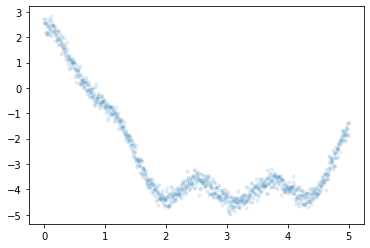

In [5]:
np.random.seed(43052)
t= np.linspace(0,5,1000)
y = -2+ 3*np.cos(t) + 1*np.cos(2*t) + 0.5*np.cos(5*t) + np.random.randn(1000)*0.2
plt.plot(t,y,'.',alpha=0.1)

tf.keras를 이용하여 $\beta_0,\dots,\beta_5$를 추정하라. ($\beta_0,\dots,\beta_5$의 참값은 각각 -2,3,1,0,0,0.5 이다) 

**(풀이)**

`-` 다시 풀어보자 

In [6]:
y = y.reshape(1000,1)
x1 = np.cos(t) 
x2 = np.cos(2*t)
x3 = np.cos(3*t)
x4 = np.cos(4*t)
x5 = np.cos(5*t)
X = tf.stack([x1,x2,x3,x4,x5],axis=1)

2022-05-25 13:13:50.646441: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [7]:
!rm -rf logs
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1)) 
net.compile(loss='mse',optimizer='adam') 
net.fit(X,y, epochs = 500, batch_size=100, validation_split=0.45, callbacks=tf.keras.callbacks.TensorBoard()) 
# 텐서보드를 이용한 시각화기능 추가 
# validation_split 이용 

Epoch 1/500
6/6 [==============================] - 1s 12ms/step - loss: 5.4903 - val_loss: 15.1618
Epoch 2/500
6/6 [==============================] - 0s 3ms/step - loss: 5.4430 - val_loss: 15.1202
Epoch 3/500
6/6 [==============================] - 0s 3ms/step - loss: 5.3966 - val_loss: 15.0790
Epoch 4/500
6/6 [==============================] - 0s 3ms/step - loss: 5.3505 - val_loss: 15.0372
Epoch 5/500
6/6 [==============================] - 0s 3ms/step - loss: 5.3057 - val_loss: 14.9959
Epoch 6/500
6/6 [==============================] - 0s 4ms/step - loss: 5.2609 - val_loss: 14.9543
Epoch 7/500
6/6 [==============================] - 0s 4ms/step - loss: 5.2149 - val_loss: 14.9135
Epoch 8/500
6/6 [==============================] - 0s 4ms/step - loss: 5.1707 - val_loss: 14.8726
Epoch 9/500
6/6 [==============================] - 0s 3ms/step - loss: 5.1264 - val_loss: 14.8313
Epoch 10/500
6/6 [==============================] - 0s 4ms/step - loss: 5.0839 - val_loss: 14.7907
Epoch 11/500
6/6 [

In [8]:
net.weights

[<tf.Variable 'dense/kernel:0' shape=(5, 1) dtype=float32, numpy=
 array([[ 2.0574358 ],
        [ 1.8425864 ],
        [-0.7131429 ],
        [ 0.5902218 ],
        [ 0.01545506]], dtype=float32)>,
 <tf.Variable 'dense/bias:0' shape=(1,) dtype=float32, numpy=array([-1.5366352], dtype=float32)>]

`-` 결과시각화: 

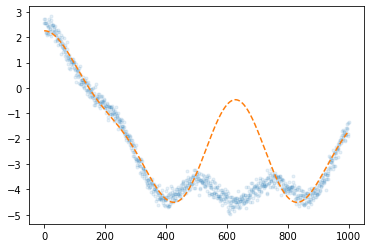

In [9]:
plt.plot(y,'.',alpha=0.1)
plt.plot(net(X),'--')

`-` 보여준데이터에서는 잘맞추는듯 하지만 validation에서 엉망이다 -> 오버피팅인가? -> 텐서보드로 확인

In [10]:
#
# %tensorboard --logdir logs --host 0.0.0.0

- 확인결과: 에폭마다 val이 같이줄어든다.. (늦게 줄어들뿐!) -> 오버피팅이라기보다는 val에 들어있는 자료를 예측하기에 데이터가 충분치 않다고 해석 (모형의 문제가 아님)

`-` 해결방법? 그냥 더 학습시키면된다. 

In [11]:
!rm -rf logs
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1)) 
net.compile(loss='mse',optimizer='adam') 
net.fit(X,y, epochs = 2000, batch_size=100, validation_split=0.45, callbacks=tf.keras.callbacks.TensorBoard()) 

Epoch 1/2000
6/6 [==============================] - 0s 9ms/step - loss: 10.3448 - val_loss: 19.0115
Epoch 2/2000
6/6 [==============================] - 0s 3ms/step - loss: 10.2823 - val_loss: 18.9557
Epoch 3/2000
6/6 [==============================] - 0s 3ms/step - loss: 10.2214 - val_loss: 18.8998
Epoch 4/2000
6/6 [==============================] - 0s 2ms/step - loss: 10.1609 - val_loss: 18.8445
Epoch 5/2000
6/6 [==============================] - 0s 2ms/step - loss: 10.0996 - val_loss: 18.7896
Epoch 6/2000
6/6 [==============================] - 0s 3ms/step - loss: 10.0396 - val_loss: 18.7343
Epoch 7/2000
6/6 [==============================] - 0s 3ms/step - loss: 9.9785 - val_loss: 18.6784
Epoch 8/2000
6/6 [==============================] - 0s 3ms/step - loss: 9.9218 - val_loss: 18.6227
Epoch 9/2000
6/6 [==============================] - 0s 3ms/step - loss: 9.8616 - val_loss: 18.5679
Epoch 10/2000
6/6 [==============================] - 0s 3ms/step - loss: 9.8033 - val_loss: 18.5134
Epo

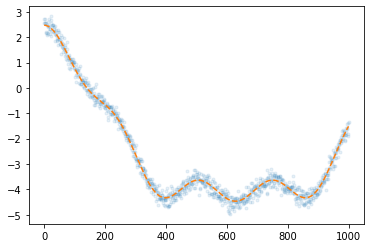

In [12]:
plt.plot(y,'.',alpha=0.1)
plt.plot(net(X),'--')

In [13]:
#
#%tensorboard --logdir logs --host 0.0.0.0

- 이런건 오버핏이 아님!

`-` 결론적으로 말해서 위와 같은 net를 설계하였을 경우 val을 나누는건 어리석음. (데이터만 버리는꼴임) 

`-` 더 많은 데이터를 남겨주면 더 빨리 학습한다. 

In [14]:
!rm -rf logs
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1)) 
net.compile(loss='mse',optimizer='adam') 
net.fit(X,y, epochs = 500, batch_size=100, validation_split=0.1, callbacks=tf.keras.callbacks.TensorBoard()) 

Epoch 1/500
9/9 [==============================] - 0s 5ms/step - loss: 11.0374 - val_loss: 7.6127
Epoch 2/500
9/9 [==============================] - 0s 2ms/step - loss: 10.9277 - val_loss: 7.5523
Epoch 3/500
9/9 [==============================] - 0s 2ms/step - loss: 10.8224 - val_loss: 7.4935
Epoch 4/500
9/9 [==============================] - 0s 1ms/step - loss: 10.7155 - val_loss: 7.4364
Epoch 5/500
9/9 [==============================] - 0s 1ms/step - loss: 10.6095 - val_loss: 7.3800
Epoch 6/500
9/9 [==============================] - 0s 2ms/step - loss: 10.5047 - val_loss: 7.3231
Epoch 7/500
9/9 [==============================] - 0s 2ms/step - loss: 10.4009 - val_loss: 7.2669
Epoch 8/500
9/9 [==============================] - 0s 1ms/step - loss: 10.2995 - val_loss: 7.2103
Epoch 9/500
9/9 [==============================] - 0s 2ms/step - loss: 10.1961 - val_loss: 7.1552
Epoch 10/500
9/9 [==============================] - 0s 2ms/step - loss: 10.0961 - val_loss: 7.1009
Epoch 11/500
9/9 [=

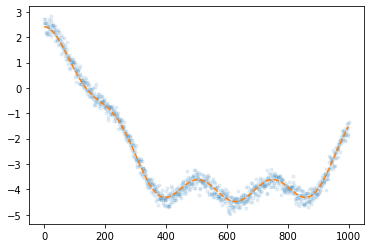

In [15]:
plt.plot(y,'.',alpha=0.1)
plt.plot(net(X),'--')

In [16]:
#
#%tensorboard --logdir logs --host 0.0.0.0

#### 텐서보드: 적합결과 시각화

`-` 텐서플로우팁추가: 적합결과시각화도 텐서플로우에서 보고싶다! (적합결과를 보여주는 figure오브젝트를 텐서플로우에 끼워넣자)

In [17]:
!rm -rf logs
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1)) 
net.compile(loss='mse',optimizer='adam') 
net.fit(X,y, epochs = 500, batch_size=100, verbose=0, validation_split=0.1, callbacks=tf.keras.callbacks.TensorBoard()) 

In [18]:
#
#%tenso4rboard --logdir logs --host 0.0.0.0

`-` 끼워넣을 오브젝트 만들기

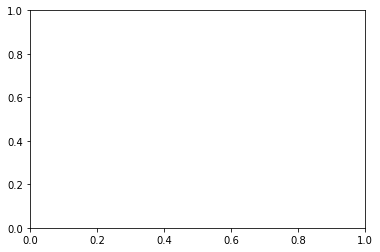

In [19]:
fig,ax = plt.subplots()

In [20]:
ax.plot(y,'.',alpha=0.1)
ax.plot(net(X),'--')

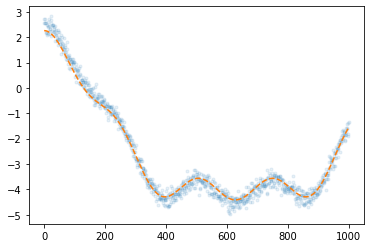

In [21]:
fig

`-` 다만듬, 이제 끼워넣는 코드를 만들자. (아니 긁어오자..) 
- https://www.tensorflow.org/tensorboard/image_summaries

In [22]:
#from datetime import datetime
import io
logdir = "logs" 

def plot_to_image(fig):
    """Converts the matplotlib plot specified by 'figure' to a PNG image and
    returns it. The supplied figure is closed and inaccessible after this call."""
    # Save the plot to a PNG in memory.
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    # Closing the figure prevents it from being displayed directly inside
    # the notebook.
    plt.close(fig)
    buf.seek(0)
    # Convert PNG buffer to TF image
    image = tf.image.decode_png(buf.getvalue(), channels=4)
    # Add the batch dimension
    image = tf.expand_dims(image, 0)
    return image

with tf.summary.create_file_writer(logdir).as_default():
    tf.summary.image("적합결과시각화", plot_to_image(fig), step=0)

In [23]:
#
#%tensorboard --logdir logs --host 0.0.0.0

- logs의 폴더를 확인하면 뭔가가 더생김

### 학습과정 분석

#### 텐서보드: 가중치시각화 

`-` 에폭별로 가중치가 수렴하는 모양을 보고싶다. 

`3-(1)` 아래와 같은 모형을 고려하자. 

$$y_i= \beta_0 + \sum_{k=1}^{5} \beta_k \cos(k t_i)+\epsilon_i$$

여기에서 $t=(t_1,\dots,t_{1000})=$ `np.linspace(0,5,1000)` 이다. 그리고 $\epsilon_i \sim i.i.d~ N(0,\sigma^2)$, 즉 서로 독립인 표준정규분포에서 추출된 샘플이다. 위의 모형에서 아래와 같은 데이터를 관측했다고 가정하자. 

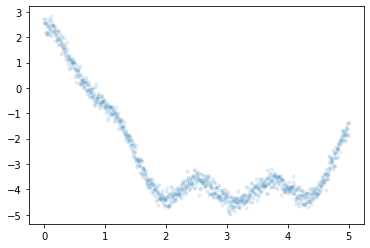

In [24]:
np.random.seed(43052)
t= np.linspace(0,5,1000)
y = -2+ 3*np.cos(t) + 1*np.cos(2*t) + 0.5*np.cos(5*t) + np.random.randn(1000)*0.2
plt.plot(t,y,'.',alpha=0.1)

tf.keras를 이용하여 $\beta_0,\dots,\beta_5$를 추정하라. ($\beta_0,\dots,\beta_5$의 참값은 각각 -2,3,1,0,0,0.5 이다) 

`-` 학습을 진행시키고 가중치를 시각화하자.

In [25]:
!rm -rf logs
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1)) 
net.compile(loss='mse',optimizer='adam') 
net.fit(X,y, epochs = 2000, batch_size=100, verbose=0, validation_split=0.45, callbacks=tf.keras.callbacks.TensorBoard(update_freq='epoch',histogram_freq=100)) 

In [26]:
net.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 1)                 6         
                                                                 
Total params: 6
Trainable params: 6
Non-trainable params: 0
_________________________________________________________________


In [27]:
net.weights

[<tf.Variable 'dense_4/kernel:0' shape=(5, 1) dtype=float32, numpy=
 array([[ 2.99854517e+00],
        [ 1.01031256e+00],
        [-1.34332245e-02],
        [-7.07113359e-05],
        [ 4.86261219e-01]], dtype=float32)>,
 <tf.Variable 'dense_4/bias:0' shape=(1,) dtype=float32, numpy=array([-2.0083973], dtype=float32)>]

In [28]:
#
#%tensorboard --logdir logs --host 0.0.0.0

#### 텐서보드: 사용자지정그림 에폭별로 시각화 (1)

`-` 100에폭마다 적합결과를 시각화 하고 싶다. 
- https://www.tensorflow.org/guide/keras/custom_callback

`-` 배운적이 있다?... (아니야)

In [29]:
!rm -rf logs
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1)) 
net.compile(loss='mse',optimizer='adam') 
net.fit(X,y, epochs = 2000, batch_size=100, verbose=0, validation_split=0.45, callbacks=tf.keras.callbacks.TensorBoard(update_freq='epoch',histogram_freq=100)) 

In [30]:
# def plot_to_image(fig):
#     """Converts the matplotlib plot specified by 'figure' to a PNG image and
#     returns it. The supplied figure is closed and inaccessible after this call."""
#     # Save the plot to a PNG in memory.
#     buf = io.BytesIO()
#     fig.savefig(buf, format='png')
#     # Closing the figure prevents it from being displayed directly inside
#     # the notebook.
#     plt.close(fig)
#     buf.seek(0)
#     # Convert PNG buffer to TF image
#     image = tf.image.decode_png(buf.getvalue(), channels=4)
#     # Add the batch dimension
#     image = tf.expand_dims(image, 0)
#     return image

fig,ax = plt.subplots()
ax.plot(y,'.',alpha=0.1)
ax.plot(net(X),'--')
with tf.summary.create_file_writer(logdir).as_default():
    tf.summary.image("적합결과시각화", plot_to_image(fig), step=0)    

In [34]:
#
#%tensorboard --logdir logs --host 0.0.0.0

`-` 아래의 코드를 100에폭마다 실행하고싶다. 다 적합하고 한번 넣는게 아니라

```python
# def plot_to_image(fig):
#     """Converts the matplotlib plot specified by 'figure' to a PNG image and
#     returns it. The supplied figure is closed and inaccessible after this call."""
#     # Save the plot to a PNG in memory.
#     buf = io.BytesIO()
#     fig.savefig(buf, format='png')
#     # Closing the figure prevents it from being displayed directly inside
#     # the notebook.
#     plt.close(fig)
#     buf.seek(0)
#     # Convert PNG buffer to TF image
#     image = tf.image.decode_png(buf.getvalue(), channels=4)
#     # Add the batch dimension
#     image = tf.expand_dims(image, 0)
#     return image

### 이부분을 100에폭마다 하고싶다!
fig,ax = plt.subplots()
ax.plot(y,'.',alpha=0.1)
ax.plot(net(X),'--')
with tf.summary.create_file_writer(logdir).as_default():
    tf.summary.image("적합결과시각화", plot_to_image(fig), step=0)
####
```

`-` 일단 네트워크 생성하고 fit직전까지 코드를 짜놓자.

In [32]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(1)) 
net.compile(loss='mse',optimizer='adam') 

`-` 사용자정의 콜백클래스 만듬 

In [35]:
class Plotyhat(tf.keras.callbacks.Callback):
    def on_epoch_end(self,epoch,logs): # 입력 무조건 self, epoch, logs 써야해요 --> 에폭이 끝날때마다 할 동작을 이 함수안에 정의한다. 
        if epoch % 100 ==0: 
            fig,ax = plt.subplots()
            ax.plot(y,'.',alpha=0.1)
            ax.plot(net(X),'--')
            with tf.summary.create_file_writer('./logs').as_default():
                tf.summary.image("적합결과시각화"+str(epoch), plot_to_image(fig), step=0)

`-` 내가 만든 클래스에서 cb2를 생성

In [36]:
cb1=tf.keras.callbacks.TensorBoard(update_freq='epoch',histogram_freq=100) 
cb2=Plotyhat()

`-` `net.fit`할때 내가 만든 콜백도 끼워넣고 학습

In [37]:
!rm -rf logs
net.fit(X,y, epochs = 2000, batch_size=100, verbose=0, validation_split=0.45, callbacks=[cb1,cb2]) 

In [39]:
#
#%tensorboard --logdir logs --host 0.0.0.0

#### 텐서보드: 사용자지정그림 에폭별로 시각화 (2) 

`-` 중간층의 출력결과를 시각화하고 싶다. 

`4`. Piecewise-linear regression (15점) 

아래의 모형을 고려하자. 

model: $y_i=\begin{cases} x_i +0.3\epsilon_i & x\leq 0 \\ 3.5x_i +0.3\epsilon_i & x>0 \end{cases}$ 

아래는 위의 모형에서 생성한 샘플이다. 

In [40]:
## data 
np.random.seed(43052)
N=100
x= np.linspace(-1,1,N).reshape(N,1)
y= np.array(list(map(lambda x: x*1+np.random.normal()*0.3 if x<0 else x*3.5+np.random.normal()*0.3,x))).reshape(N,1)

(풀이)

In [41]:
tf.random.set_seed(43055) # 43055 잘되는씨드 , 43059 망하는 씨드 
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(2))
net.add(tf.keras.layers.Activation(tf.nn.relu))
net.add(tf.keras.layers.Dense(1))
net.compile(optimizer='sgd',loss='mse')

In [42]:
l1,a1,l2 = net.layers

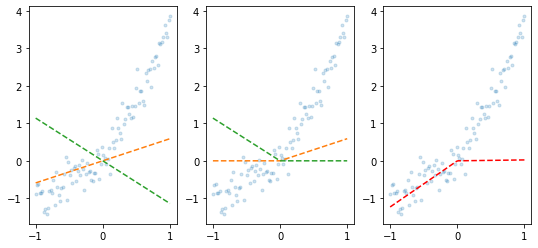

In [43]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3)
fig.set_figwidth(9)
ax1.plot(x,y,'.',alpha=0.2);ax1.plot(x,l1(x),'--')
ax2.plot(x,y,'.',alpha=0.2);ax2.plot(x,a1(l1(x)),'--')
ax3.plot(x,y,'.',alpha=0.2);ax3.plot(x,l2(a1(l1(x))),'r--')

- 이런그림이 100에폭마다 그려지면 좋겠다

학습과정을 에폭별로 시각화

In [44]:
!rm -rf logs
class PlotMidlayer(tf.keras.callbacks.Callback):
    def on_epoch_end(self,epoch,logs): # 입력 무조건 self, epoch, logs 써야해요
        if epoch % 100 ==0: 
            fig, (ax1,ax2,ax3) = plt.subplots(1,3)
            fig.set_figwidth(9)
            ax1.plot(x,y,'.',alpha=0.2);ax1.plot(x,l1(x),'--')
            ax2.plot(x,y,'.',alpha=0.2);ax2.plot(x,a1(l1(x)),'--')
            ax3.plot(x,y,'.',alpha=0.2);ax3.plot(x,l2(a1(l1(x))),'--')
            with tf.summary.create_file_writer('logs').as_default():
                tf.summary.image("중간층시각화"+str(epoch), plot_to_image(fig), step=0)

In [46]:
!kill 1987275

In [ ]:
cb1=tf.keras.callbacks.TensorBoard(update_freq='epoch',histogram_freq=100) 
cb2=PlotMidlayer()
net.fit(x,y, epochs = 1000, batch_size=100, verbose=0, callbacks=[cb1,cb2]) 
#%tensorboard --logdir logs --host 0.0.0.0